# Libraries

In [1]:
from dotenv import load_dotenv
from pathlib import Path
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bring the data from kaggle and see the first rows

In [8]:
load_dotenv()
# kagglehub.login()
data_dir = Path(kagglehub.competition_download("house-prices-advanced-regression-techniques"))

train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv")
train.head()

KaggleApiHTTPError: 401 Client Error.

You don't have permission to access resource at URL: https://kaggle.com/competitions/house-prices-advanced-regression-techniques
Please make sure you are authenticated and have accepted the competition rules which can be found at this location: https://kaggle.com/competitions/house-prices-advanced-regression-techniques/rules

# Select only the columns that we want

In [4]:
datos = train[["SalePrice", "OverallQual", "GrLivArea", "TotalBsmtSF","YearBuilt", "YrSold", "GarageArea", "Neighborhood"]].copy()
datos.info()

NameError: name 'train' is not defined

## Fisrt question:  

### 1) How much combined living and basement space is?

In [ ]:
datos['combined_space'] = datos['GrLivArea'] + datos['TotalBsmtSF']
datos.head()

,SalePrice,OverallQual,GrLivArea,TotalBsmtSF,YearBuilt,YrSold,GarageArea,Neighborhood,combined_space
0,208500,7,1710,856,2003,2008,548,CollgCr,2566
1,181500,6,1262,1262,1976,2007,460,Veenker,2524
2,223500,7,1786,920,2001,2008,608,CollgCr,2706
3,140000,7,1717,756,1915,2006,642,Crawfor,2473
4,250000,8,2198,1145,2000,2008,836,NoRidge,3343


## Second question:

### 2) How old was the house when sold?

In [ ]:
datos['years_old'] = datos['YrSold'] - datos['YearBuilt']
datos.head()

,SalePrice,OverallQual,GrLivArea,TotalBsmtSF,YearBuilt,YrSold,GarageArea,Neighborhood,combined_space,years_old
0,208500,7,1710,856,2003,2008,548,CollgCr,2566,5
1,181500,6,1262,1262,1976,2007,460,Veenker,2524,31
2,223500,7,1786,920,2001,2008,608,CollgCr,2706,7
3,140000,7,1717,756,1915,2006,642,Crawfor,2473,91
4,250000,8,2198,1145,2000,2008,836,NoRidge,3343,8


## Third question

### 3) How much bathroom capacity is there?

In [ ]:
datos['bathrooms_capacity'] = train['FullBath'] + train['BsmtFullBath'] + train['HalfBath'] + train['BsmtHalfBath']
datos.head()

,SalePrice,OverallQual,GrLivArea,TotalBsmtSF,YearBuilt,YrSold,GarageArea,Neighborhood,combined_space,years_old,bathrooms_capacity
0,208500,7,1710,856,2003,2008,548,CollgCr,2566,5,4
1,181500,6,1262,1262,1976,2007,460,Veenker,2524,31,3
2,223500,7,1786,920,2001,2008,608,CollgCr,2706,7,4
3,140000,7,1717,756,1915,2006,642,Crawfor,2473,91,2
4,250000,8,2198,1145,2000,2008,836,NoRidge,3343,8,4


## Fourth question

### 4) Does a large, high-quality house differ from a large, low-quality one?

In [ ]:
datos['total_area'] = datos['combined_space'] + datos['GarageArea']
threshold = np.quantile(datos['total_area'],0.75)
datos['is_large'] = np.where(datos['total_area'] >= threshold, 1, 0)
# datos['is_HQ'] = np.where(datos['OverallQual'] >= 8, 1, 0)
# datos['is_LQ'] = np.where(datos['OverallQual'] <= 5, 1, 0)
datos['Quality'] = np.where(datos['OverallQual'] >= 8, 'HQ', np.where(datos['OverallQual'] <= 5, 'LQ', 'MQ'))
datos.head()

,SalePrice,OverallQual,GrLivArea,TotalBsmtSF,YearBuilt,YrSold,GarageArea,Neighborhood,combined_space,years_old,bathrooms_capacity,total_area,is_large,is_HQ,is_LQ
0,208500,7,1710,856,2003,2008,548,CollgCr,2566,5,4,3114,0,0,0
1,181500,6,1262,1262,1976,2007,460,Veenker,2524,31,3,2984,0,0,0
2,223500,7,1786,920,2001,2008,608,CollgCr,2706,7,4,3314,0,0,0
3,140000,7,1717,756,1915,2006,642,Crawfor,2473,91,2,3115,0,0,0
4,250000,8,2198,1145,2000,2008,836,NoRidge,3343,8,4,4179,1,1,0


In [ ]:
datos_large = datos[datos['is_large'] == 1]
# datos_large_HQ = datos[ (datos['is_large'] == 1) & (datos['Quality'] == 'HQ') ]
# datos_large_LQ = datos[ (datos['is_large'] == 1) & (datos['Quality'] == 'LQ') ]
datos_large_extremos = datos_large[datos_large['Quality'] != 'MQ']

,SalePrice,OverallQual,GrLivArea,TotalBsmtSF,YearBuilt,YrSold,GarageArea,Neighborhood,combined_space,years_old,bathrooms_capacity,total_area,is_large,is_HQ,is_LQ
4,250000,8,2198,1145,2000,2008,836,NoRidge,3343,8,4,4179,1,1,0
6,307000,8,1694,1686,2004,2007,636,Somerst,3380,3,3,4016,1,1,0
11,345000,9,2324,1175,2005,2006,736,NridgHt,3499,1,4,4235,1,1,0
20,325300,8,2376,1158,2005,2006,853,NridgHt,3534,1,4,4387,1,1,0
22,230000,8,1795,1777,2002,2008,534,CollgCr,3572,6,2,4106,1,1,0


,SalePrice,OverallQual,GrLivArea,TotalBsmtSF,YearBuilt,YrSold,GarageArea,Neighborhood,combined_space,years_old,bathrooms_capacity,total_area,is_large,is_HQ,is_LQ
134,180000,5,1721,1461,1968,2006,440,Sawyer,3182,38,3,3622,1,0,1
144,125000,5,1728,1728,1963,2006,504,Sawyer,3456,43,3,3960,1,0,1
166,190000,5,1867,1617,1955,2009,303,ClearCr,3484,54,2,3787,1,0,1
330,119000,5,1728,1728,1964,2007,352,NAmes,3456,43,3,3808,1,0,1
335,228950,5,1786,1499,1965,2008,529,Timber,3285,43,4,3814,1,0,1


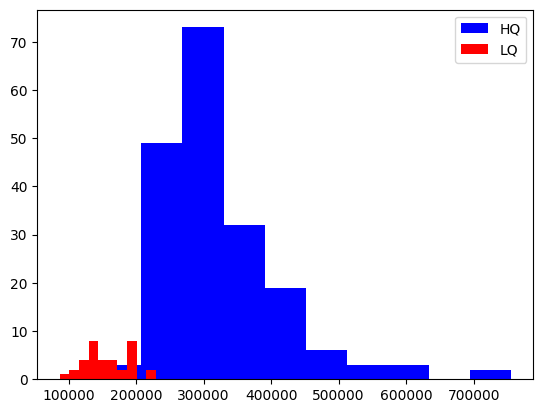

In [ ]:
media_precio_HQ = datos_large_extremos[datos_large_extremos['Quality'] == 'HQ']['SalePrice'].mean()
media_precio_LQ = datos_large_extremos[datos_large_extremos['Quality'] == 'LQ']['SalePrice'].mean()

plt.figure(figsize=(10, 5))
sns.histplot(data=datos_large_extremos, x='SalePrice', hue='Quality',
             palette={'HQ': 'lightblue', 'LQ': 'pink'},
             alpha=0.7, bins=30)
plt.axvline(media_precio_HQ, color='blue', linestyle='--', label=f'Media Precio HQ: ${media_precio_HQ:.2f}')
plt.axvline(media_precio_LQ, color='red', linestyle='--', label=f'Media Precio LQ: ${media_precio_LQ:.2f}')
plt.xlabel('Sales Price ($)', fontsize = 14)
plt.ylabel('Houses', fontsize = 14)
plt.title('Distribution of Sales Price by Quality', fontsize = 16)
plt.legend()
plt.grid()
sns.despine()


<Axes: >

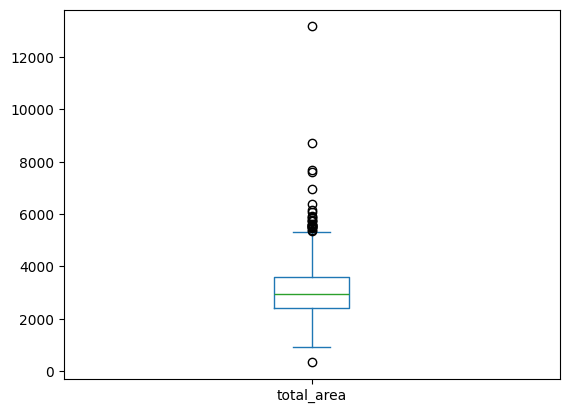

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=datos_large_extremos, x='Quality', y='SalePrice', width=0.5,
            palette={'HQ': 'lightblue', 'LQ': 'pink'})
plt.xlabel('House Quality', fontsize=12)
plt.ylabel('Sales Price ($)', fontsize=12)
plt.title('Distribution of Sales Price in Large Houses: HQ vs LQ', fontsize=14)
sns.despine()